# 🔍 EDA – Digit Detection Dataset

Checking data quality using:
- 🖼️ **FiftyOne** – visualize COCO dataset, browse samples, analyze labels
- 🧹 **CleanVision** – detect image quality issues (near-duplicate, blur, dark/bright, low-info)
- 🏷️ **Cleanlab** – detect label noise (wrong annotations, abnormal bboxes)

📂 Dataset: `data/train/` + `data/train.json` (COCO format, 10 classes = digits 0–9)

## 1. ⚙️ Setup & Constants

In [1]:
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

ROOT = Path("../data")
TRAIN_DIR  = ROOT / "train"
VALID_DIR  = ROOT / "valid"
TRAIN_JSON = ROOT / "train.json"
VALID_JSON = ROOT / "valid.json"
NOTEBOOK_DIR = Path("notebooks").parent.absolute()
OUTPUT = os.path.join(NOTEBOOK_DIR, "outputs")
os.makedirs(OUTPUT, exist_ok=True)

with open(TRAIN_JSON) as f:
    train_coco = json.load(f)
with open(VALID_JSON) as f:
    valid_coco = json.load(f)

# category_id -> digit string
CATS = {c["id"]: c["name"] for c in train_coco["categories"]}
print("Categories:", CATS)
print(f"Train images : {len(train_coco['images']):,}")
print(f"Train annotations: {len(train_coco['annotations']):,}")
print(f"Valid images : {len(valid_coco['images']):,}")
print(f"Valid annotations: {len(valid_coco['annotations']):,}")

Categories: {1: '0', 2: '1', 3: '2', 4: '3', 5: '4', 6: '5', 7: '6', 8: '7', 9: '8', 10: '9'}
Train images : 30,062
Train annotations: 65,960
Valid images : 3,340
Valid annotations: 7,297


## 2. 📊 Basic Statistics

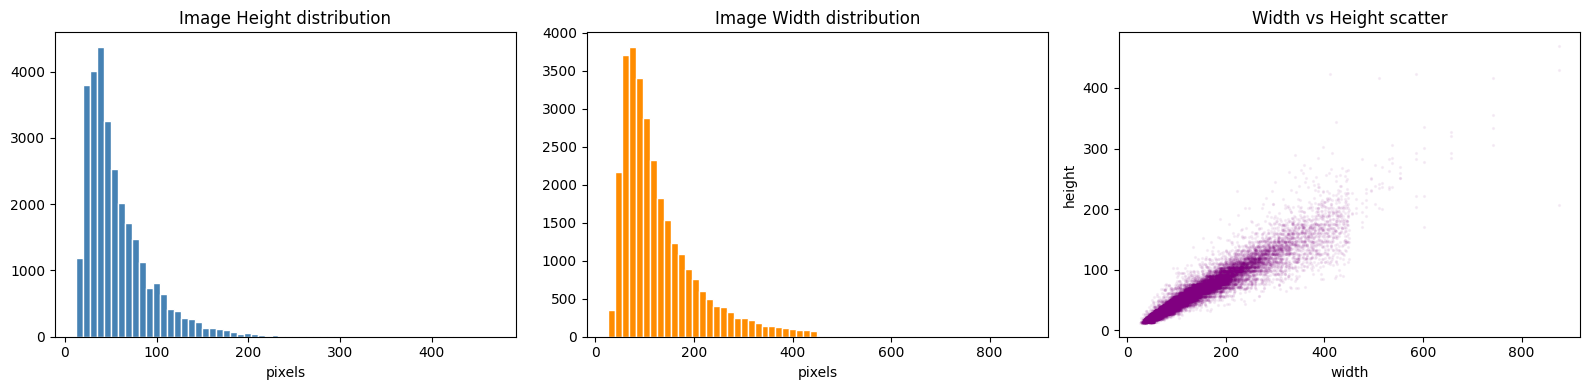

Height min=12, max=469, mean=57.2, median=47
Width min=25,  max=876,  mean=128.2,  median=104


In [12]:
heights = [i["height"] for i in train_coco["images"]]
widths  = [i["width"]  for i in train_coco["images"]]
areas   = [h * w for h, w in zip(heights, widths)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(heights, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Image Height distribution")
axes[0].set_xlabel("pixels")

axes[1].hist(widths, bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Image Width distribution")
axes[1].set_xlabel("pixels")

axes[2].scatter(widths, heights, alpha=0.05, s=2, color="purple")
axes[2].set_title("Width vs Height scatter")
axes[2].set_xlabel("width"); axes[2].set_ylabel("height")

plt.tight_layout()
plt.show()

print(f"Height min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}, median={np.median(heights):.0f}")
print(f"Width min={min(widths)},  max={max(widths)},  mean={np.mean(widths):.1f},  median={np.median(widths):.0f}")

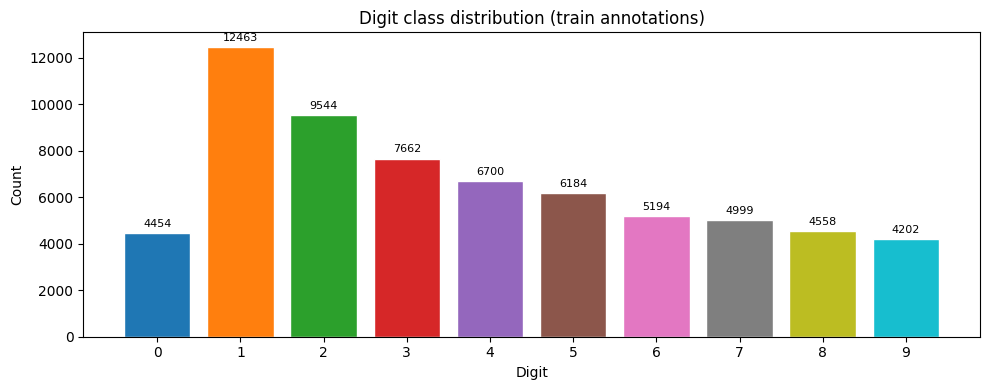

  digit 0:  4454  (6.8%)
  digit 1: 12463  (18.9%)
  digit 2:  9544  (14.5%)
  digit 3:  7662  (11.6%)
  digit 4:  6700  (10.2%)
  digit 5:  6184  (9.4%)
  digit 6:  5194  (7.9%)
  digit 7:  4999  (7.6%)
  digit 8:  4558  (6.9%)
  digit 9:  4202  (6.4%)


In [13]:
cat_count = Counter(a["category_id"] for a in train_coco["annotations"])
labels = [CATS[k] for k in sorted(cat_count)]
counts = [cat_count[k] for k in sorted(cat_count)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_title("Digit class distribution (train annotations)")
ax.set_xlabel("Digit"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

total = sum(counts)
for lbl, cnt in zip(labels, counts):
    print(f"  digit {lbl}: {cnt:5d}  ({cnt/total*100:.1f}%)")

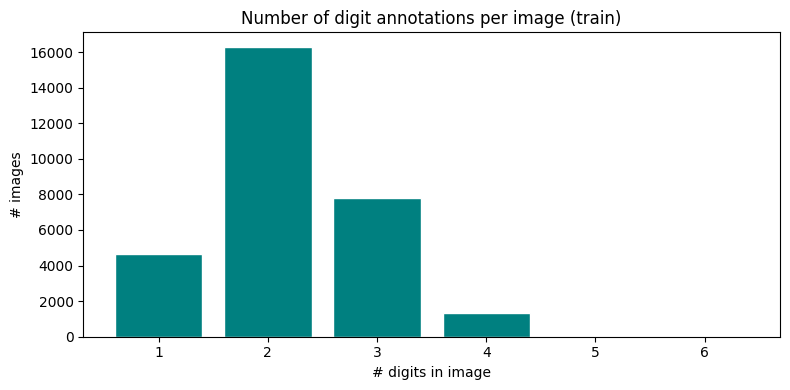

Distribution: {1: 4636, 2: 16295, 3: 7801, 4: 1320, 5: 9, 6: 1}


In [14]:
ann_per_img = Counter(a["image_id"] for a in train_coco["annotations"])
vals = list(ann_per_img.values())

fig, ax = plt.subplots(figsize=(8, 4))
cnt = Counter(vals)
ax.bar(cnt.keys(), cnt.values(), color="teal", edgecolor="white")
ax.set_title("Number of digit annotations per image (train)")
ax.set_xlabel("# digits in image"); ax.set_ylabel("# images")
plt.tight_layout()
plt.show()
print("Distribution:", dict(sorted(cnt.items())))

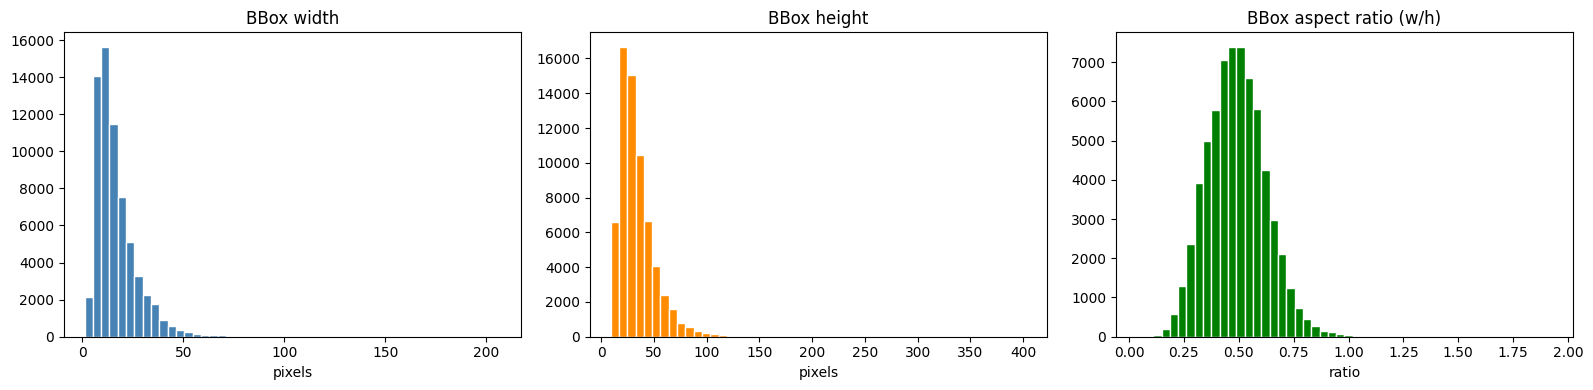

In [15]:
# ---- bbox size distribution ----
bbox_w = [a["bbox"][2] for a in train_coco["annotations"]]
bbox_h = [a["bbox"][3] for a in train_coco["annotations"]]
bbox_ar = [w / max(h, 1) for w, h in zip(bbox_w, bbox_h)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(bbox_w, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("BBox width"); axes[0].set_xlabel("pixels")

axes[1].hist(bbox_h, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("BBox height"); axes[1].set_xlabel("pixels")

axes[2].hist(bbox_ar, bins=50, color="green", edgecolor="white")
axes[2].set_title("BBox aspect ratio (w/h)"); axes[2].set_xlabel("ratio")

plt.tight_layout()
plt.show()

## 3. 🖼️ Sample Visualization with Annotations

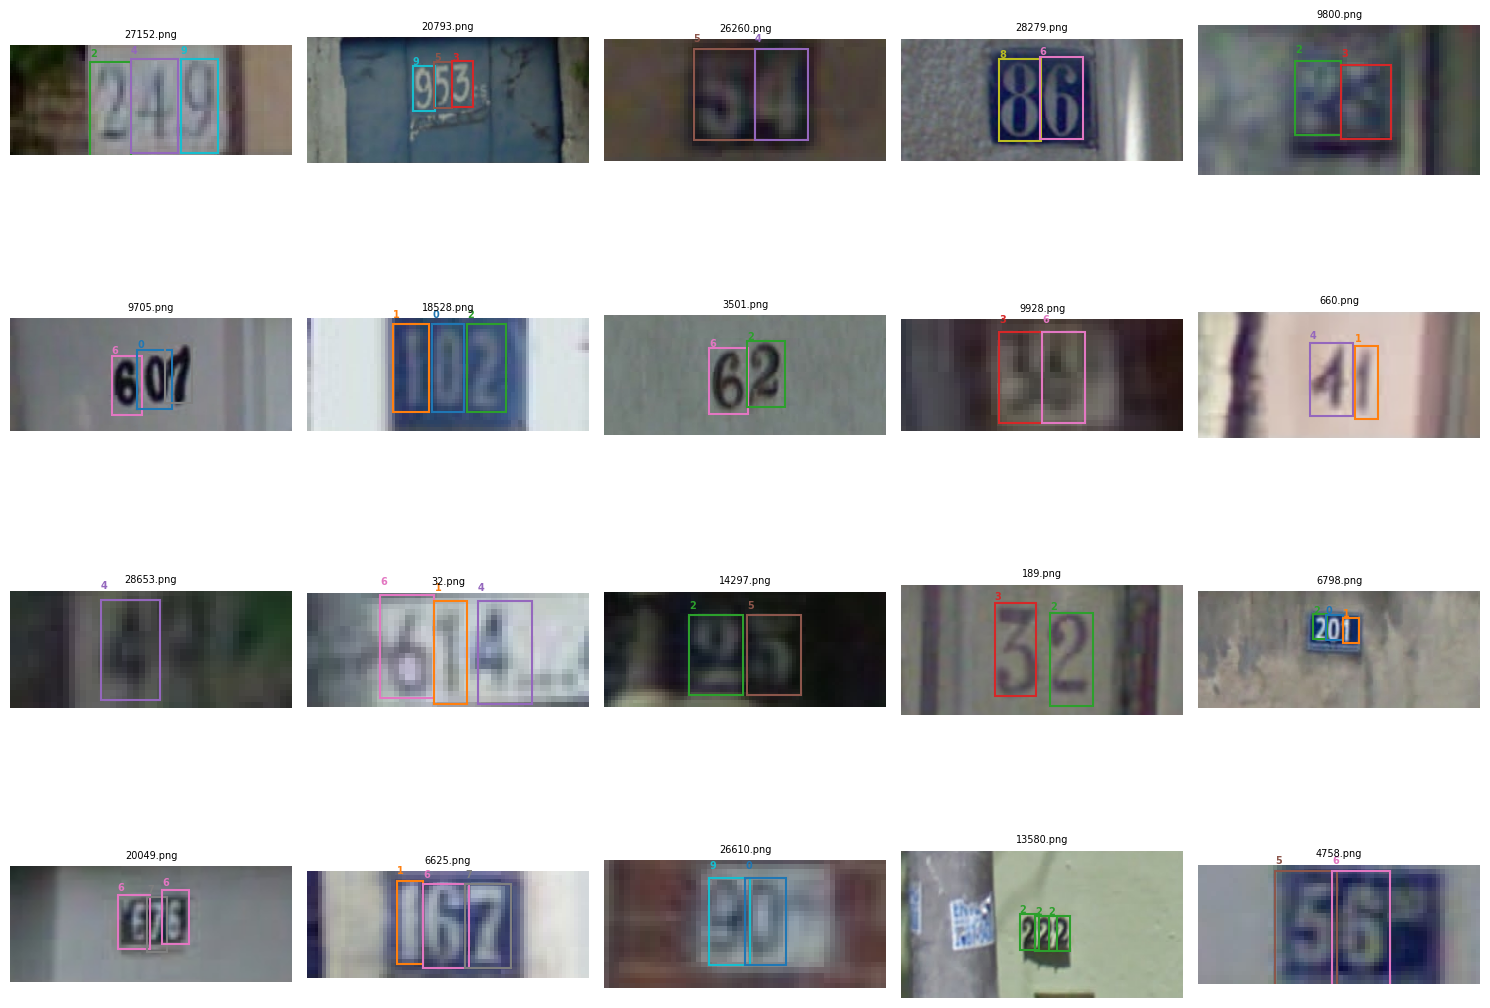

In [16]:
img_by_id = {i["id"]: i for i in train_coco["images"]}
ann_by_img = defaultdict(list)
for a in train_coco["annotations"]:
    ann_by_img[a["image_id"]].append(a)

COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

def show_samples(image_ids, img_dir, ncols=5):
    nrows = (len(image_ids) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten()
    for ax, img_id in zip(axes, image_ids):
        meta = img_by_id[img_id]
        img_path = img_dir / meta["file_name"]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        for ann in ann_by_img[img_id]:
            x, y, w, h = ann["bbox"]
            cat_idx = ann["category_id"] - 1
            rect = patches.Rectangle((x, y), w, h,
                                      linewidth=1.5, edgecolor=COLORS[cat_idx], facecolor="none")
            ax.add_patch(rect)
            ax.text(x, y - 2, CATS[ann["category_id"]], color=COLORS[cat_idx],
                    fontsize=7, fontweight="bold")
        ax.set_title(meta["file_name"], fontsize=7)
        ax.axis("off")
    for ax in axes[len(image_ids):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_ids = random.sample(list(img_by_id.keys()), 20)
show_samples(sample_ids, TRAIN_DIR)

## 4. 🔭 FiftyOne – Interactive Dataset Browser

In [7]:
import fiftyone as fo
import fiftyone.zoo as foz

DATASET_NAME = "digit-detection-train"

# Xoá dataset cũ nếu tồn tại để re-load
if fo.dataset_exists(DATASET_NAME):
    fo.delete_dataset(DATASET_NAME)

# Load COCO detection dataset vào FiftyOne
dataset = fo.Dataset.from_dir(
    dataset_type=fo.types.COCODetectionDataset,
    data_path=str(TRAIN_DIR),
    labels_path=str(TRAIN_JSON),
    name=DATASET_NAME,
    label_types=["detections"],
)
dataset.persistent = True
print(dataset)

/home/longpm/miniconda3/envs/selected-topics/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


 100% |█████████████| 30062/30062 [1.2m elapsed, 0s remaining, 287.2 samples/s]      
Name:        digit-detection-train
Media type:  image
Num samples: 30062
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


In [8]:
print("Dataset info:")
print(f"  Num samples : {len(dataset)}")
print(f"  Label field : {dataset.get_field_schema()}")

counts = dataset.count_values("ground_truth.detections.label")
print("\nLabel counts:")
for label, cnt in sorted(counts.items(), key=lambda x: int(x[0])):
    print(f"  digit {label}: {cnt}")

Dataset info:
  Num samples : 30062
  Label field : OrderedDict([('id', <fiftyone.core.fields.ObjectIdField object at 0x7f4268989150>), ('filepath', <fiftyone.core.fields.StringField object at 0x7f426898a150>), ('tags', <fiftyone.core.fields.ListField object at 0x7f4268988750>), ('metadata', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f4268989fd0>), ('created_at', <fiftyone.core.fields.DateTimeField object at 0x7f4268988c50>), ('last_modified_at', <fiftyone.core.fields.DateTimeField object at 0x7f428657d090>), ('ground_truth', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f426898bf50>)])

Label counts:
  digit 0: 4454
  digit 1: 12463
  digit 2: 9544
  digit 3: 7662
  digit 4: 6700
  digit 5: 6184
  digit 6: 5194
  digit 7: 4999
  digit 8: 4558
  digit 9: 4202


In [ ]:
session = fo.launch_app(dataset, auto=False)
session.show(height=800)

In [10]:
many_digits = dataset.filter_labels(
    "ground_truth",
    fo.ViewExpression(True)
).match(
    fo.ViewField("ground_truth.detections").length() >= 5
)
print(f"Images have greater than 5 detections: {len(many_digits)}")
# session.view = many_digits

Images have greater than 5 detections: 10


In [12]:
# Ảnh có bbox rất nhỏ (w < 5 hoặc h < 5 pixels) → potential noise
tiny_bbox = dataset.filter_labels(
    "ground_truth",
    (fo.ViewField("bounding_box")[2] * fo.ViewField("metadata.width") < 5) |
    (fo.ViewField("bounding_box")[3] * fo.ViewField("metadata.height") < 5)
)
print(f"Images with tiny bounding boxes (< 5px): {len(tiny_bbox)}")
# session.view = tiny_bbox

Images with tiny bounding boxes (< 5px): 30062


## 5. 🧹 CleanVision – Image Quality Issues

In [13]:
from cleanvision import Imagelab

all_train_imgs = sorted(TRAIN_DIR.glob("*.png"))
image_paths = [str(p) for p in all_train_imgs]
print(f"Number of images added to CleanVision: {len(image_paths)}")

Number of images added to CleanVision: 30062


Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 30062/30062 [01:38<00:00, 304.48it/s]


Issue checks completed. 8281 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | blurry           |         6057 |
|  1 | odd_aspect_ratio |         1800 |
|  2 | odd_size         |          240 |
|  3 | dark             |          182 |
|  4 | near_duplicates  |            2 |
|  5 | low_information  |            0 |
|  6 | light            |            0 |
|  7 | grayscale        |            0 |
|  8 | exact_duplicates |            0 | 

---------------------- blurry images -----------------------

Number of examples with this issue: 6057
Examples representing most severe instances of this issue:



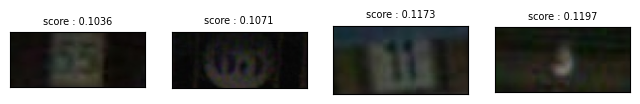

----------------- odd_aspect_ratio images ------------------

Number of examples with this issue: 1800
Examples representing most severe instances of this issue:



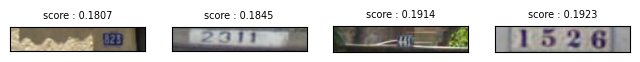

--------------------- odd_size images ----------------------

Number of examples with this issue: 240
Examples representing most severe instances of this issue:



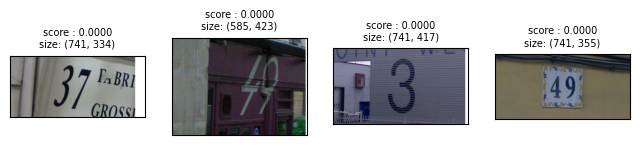

----------------------- dark images ------------------------

Number of examples with this issue: 182
Examples representing most severe instances of this issue:



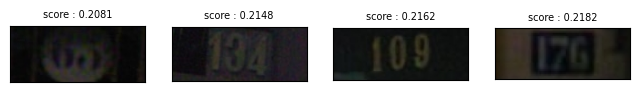

------------------ near_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


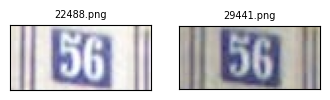

In [14]:
imagelab = Imagelab(filepaths=image_paths)
imagelab.find_issues()
imagelab.report()

In [15]:
# Lấy summary các issue
issue_summary = imagelab.issue_summary
print(issue_summary.to_string())

         issue_type  num_images
0            blurry        6057
1  odd_aspect_ratio        1800
2          odd_size         240
3              dark         182
4   near_duplicates           2
5   low_information           0
6             light           0
7         grayscale           0
8  exact_duplicates           0


In [16]:
near_dup_issues = imagelab.issues[
    imagelab.issues["is_near_duplicates_issue"] == True
]
print(f"Near-duplicate images: {len(near_dup_issues)}")
near_dup_issues.head(20)

Near-duplicate images: 2


,odd_size_score,is_odd_size_issue,odd_aspect_ratio_score,is_odd_aspect_ratio_issue,low_information_score,is_low_information_issue,light_score,is_light_issue,grayscale_score,is_grayscale_issue,dark_score,is_dark_issue,blurry_score,is_blurry_issue,exact_duplicates_score,is_exact_duplicates_issue,near_duplicates_score,is_near_duplicates_issue
../data/train/22488.png,0.929342,False,0.458333,False,0.843117,False,0.559646,False,1,False,0.989801,False,0.547235,False,1.0,False,0.5,True
../data/train/29441.png,0.926650,False,0.450704,False,0.841713,False,0.693328,False,1,False,0.797110,False,0.466507,False,1.0,False,0.5,True


Set: 0


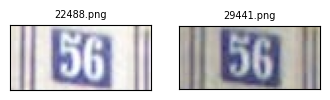

In [17]:
imagelab.visualize(issue_types=["near_duplicates"], num_images=2)

Blurry images: 6057


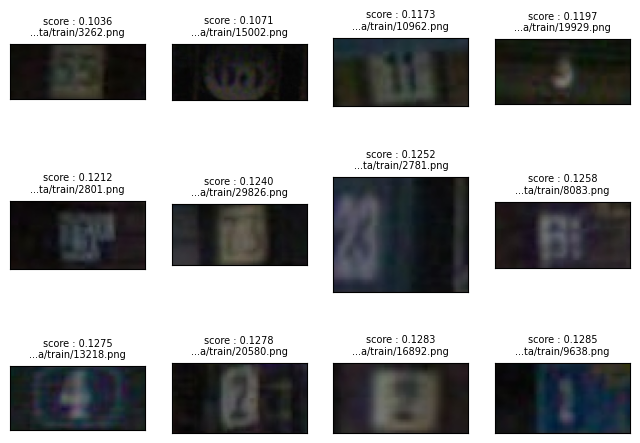

In [18]:
if "is_blurry_issue" in imagelab.issues.columns:
    blurry = imagelab.issues[imagelab.issues["is_blurry_issue"] == True]
    print(f"Blurry images: {len(blurry)}")
    imagelab.visualize(issue_types=["blurry"], num_images=12, show_id=True)
else:
    print("No blurry images found")

In [18]:
for issue_type in ["dark", "light", "low_information", "odd_aspect_ratio", "odd_size"]:
    col = f"is_{issue_type}_issue"
    if col in imagelab.issues.columns:
        cnt = imagelab.issues[col].sum()
        print(f"{issue_type}: {cnt} images")

dark: 182 images
light: 0 images
low_information: 0 images
odd_aspect_ratio: 1800 images
odd_size: 240 images


In [19]:
issues_df = imagelab.issues.copy()
issues_df["filepath"] = image_paths
issue_cols = [c for c in issues_df.columns if c.startswith("is_") and c.endswith("_issue")]
issues_df["has_any_issue"] = issues_df[issue_cols].any(axis=1)
problematic = issues_df[issues_df["has_any_issue"]]
print(f"Total number of images with at least one issue: {len(problematic)}")
problematic.to_csv(os.path.join(OUTPUT, "cleanvision_issues.csv"), index=False)
problematic[issue_cols + ["filepath"]].head(10)

Total number of images with at least one issue: 7970


,is_odd_size_issue,is_odd_aspect_ratio_issue,is_low_information_issue,is_light_issue,is_grayscale_issue,is_dark_issue,is_blurry_issue,is_exact_duplicates_issue,is_near_duplicates_issue,filepath
../data/train/1.png,False,False,False,False,False,False,True,False,False,../data/train/1.png
../data/train/1001.png,False,False,False,False,False,False,True,False,False,../data/train/1001.png
../data/train/10011.png,False,True,False,False,False,False,False,False,False,../data/train/10011.png
../data/train/10013.png,False,False,False,False,False,False,True,False,False,../data/train/10013.png
../data/train/10019.png,False,False,False,False,False,False,True,False,False,../data/train/10019.png
../data/train/1002.png,False,False,False,False,False,False,True,False,False,../data/train/1002.png
../data/train/10020.png,False,True,False,False,False,False,False,False,False,../data/train/10020.png
../data/train/10022.png,False,False,False,False,False,False,True,False,False,../data/train/10022.png
../data/train/10023.png,False,True,False,False,False,False,False,False,False,../data/train/10023.png
../data/train/10026.png,False,False,False,False,False,False,True,False,False,../data/train/10026.png


## 6. 🔗 FiftyOne + CleanVision – Display Issues in App

In [20]:
path_to_issues = {}
for _, row in issues_df.iterrows():
    active_issues = [c.replace("is_", "").replace("_issue", "")
                     for c in issue_cols if row[c]]
    if active_issues:
        path_to_issues[row["filepath"]] = active_issues

for sample in dataset.iter_samples(autosave=True):
    fp = sample.filepath
    if fp in path_to_issues:
        sample.tags = list(set(sample.tags or []) | set(path_to_issues[fp]))

print("Total number of images with CleanVision issues added to FiftyOne dataset")
print("Tag counts:", dataset.count_sample_tags())

Total number of images with CleanVision issues added to FiftyOne dataset
Tag counts: {}


In [21]:
issue_view = dataset.match_tags(["near_duplicates", "blurry", "dark", "light",
                                  "low_information", "odd_aspect_ratio"],
                                 bool=True)
print(f"Ảnh có issue (FiftyOne view): {len(issue_view)}")
session.view = issue_view

Ảnh có issue (FiftyOne view): 0


## 7. 🏷️ Cleanlab – Label Quality (Annotation Noise Detection)

Cleanlab for object detection requires model predictions to compute label quality scores.
Here we use a **heuristic-based** approach:
- 🔁 Detect bboxes with high IoU between annotations in the same image (duplicate annotations)
- 🚫 Detect out-of-bound bboxes (extending beyond image boundaries)
- ⚖️ Detect class imbalance anomalies
- 🤖 If model predictions are available: use `cleanlab.object_detection` to compute label quality

In [22]:
import warnings
warnings.filterwarnings("ignore")

oob_list = []
for ann in train_coco["annotations"]:
    img = img_by_id[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    if x < 0 or y < 0 or (x + w) > img["width"] or (y + h) > img["height"]:
        oob_list.append({
            "ann_id": ann["id"],
            "image_id": ann["image_id"],
            "file_name": img["file_name"],
            "bbox": ann["bbox"],
            "img_size": (img["width"], img["height"]),
            "category": CATS[ann["category_id"]],
        })

print(f"Bbox out-of-bound: {len(oob_list)}")
if oob_list:
    df_oob = pd.DataFrame(oob_list)
    print(df_oob.head(10))

Bbox out-of-bound: 163
   ann_id  image_id file_name                        bbox    img_size category
0     380       173   173.png    [43.0, 39.0, 24.0, 30.0]   (141, 64)        2
1     812       377   377.png      [33.0, 3.0, 9.0, 23.0]    (62, 25)        0
2    1441       659   659.png      [26.0, 3.0, 8.0, 16.0]    (53, 18)        8
3    1496       684   684.png    [-1.0, 26.0, 16.0, 34.0]   (112, 56)        3
4    2295      1050  1050.png      [11.0, 1.0, 6.0, 17.0]    (36, 13)        4
5    2528      1155  1155.png     [78.0, 8.0, 29.0, 63.0]   (157, 69)        7
6    2567      1175  1175.png      [23.0, 3.0, 6.0, 11.0]    (46, 13)        8
7    3037      1392  1392.png  [232.0, 98.0, 117.0, 98.0]  (485, 188)        6
8    3270      1494  1494.png   [150.0, 36.0, 15.0, 35.0]  (164, 104)        8
9    3627      1654  1654.png     [40.0, 6.0, 13.0, 36.0]    (84, 40)        3


In [23]:
def iou(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xa = max(x1, x2); ya = max(y1, y2)
    xb = min(x1+w1, x2+w2)
    yb = min(y1+h1, y2+h2)
    inter = max(0, xb-xa) * max(0, yb-ya)
    union = w1*h1 + w2*h2 - inter
    return inter / max(union, 1e-6)

dup_anns = []
for img_id, anns in ann_by_img.items():
    for i in range(len(anns)):
        for j in range(i+1, len(anns)):
            score = iou(anns[i]["bbox"], anns[j]["bbox"])
            if score > 0.8:
                dup_anns.append({
                    "image_id": img_id,
                    "file_name": img_by_id[img_id]["file_name"],
                    "ann1_id": anns[i]["id"], "cat1": CATS[anns[i]["category_id"]],
                    "ann2_id": anns[j]["id"], "cat2": CATS[anns[j]["category_id"]],
                    "iou": round(score, 3),
                })

print(f"Duplicate annotations (IoU>0.8): {len(dup_anns)}")
if dup_anns:
    pd.DataFrame(dup_anns).head(20)

Duplicate annotations (IoU>0.8): 2


In [24]:
tiny_anns = [
    {"ann_id": a["id"], "image_id": a["image_id"],
     "file_name": img_by_id[a["image_id"]]["file_name"],
     "bbox": a["bbox"], "category": CATS[a["category_id"]]}
    for a in train_coco["annotations"]
    if a["bbox"][2] < 3 or a["bbox"][3] < 3
]
print(f"Tiny bbox (<3px): {len(tiny_anns)}")
if tiny_anns:
    pd.DataFrame(tiny_anns).head(20)

Tiny bbox (<3px): 10


### 7.4 🤖 Cleanlab + DINO-R50 (detrex) – Label Quality with Model Predictions

In [25]:
import urllib.request
from pathlib import Path
import detectron2
import detrex
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog

DATA_ROOT = Path('../data')
CKPT_DIR  = Path('../checkpoints/pretrained')
CKPT_DIR.mkdir(exist_ok=True)

for split, img_dir, ann_file in [
    ('digit_train', DATA_ROOT / 'train', DATA_ROOT / 'train.json'),
    ('digit_valid', DATA_ROOT / 'valid', DATA_ROOT / 'valid.json'),
]:
    if split in DatasetCatalog:
        DatasetCatalog.remove(split)
    register_coco_instances(split, {}, str(ann_file), str(img_dir))
    meta = MetadataCatalog.get(split)
    meta.thing_classes = [str(i) for i in range(10)]  # digit 0–9
    print(f'Registered: {split} ({len(DatasetCatalog.get(split))} samples)')

DINO_CKPT = CKPT_DIR / 'new_align_detr_24ep.pth'

Registered: digit_train (30062 samples)
Registered: digit_valid (3340 samples)


In [26]:
# DINO_URL = "https://github.com/linxid/Focus-DETR-mindspore/releases/download/Focus-DETR/focus_detr_r101_4scale_36ep_v2.zip"

# if not DINO_CKPT.exists():
#     print('Downloading DINO-R50 checkpoint...')
#     urllib.request.urlretrieve(DINO_URL, DINO_CKPT)
#     print(f'Saved to {DINO_CKPT}')
# else:
#     print(f'Checkpoint found: {DINO_CKPT}')

In [33]:
import torch
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.data import (
    build_detection_train_loader, 
    build_detection_test_loader,
    DatasetMapper,
)

DEVICE = 'cuda:7' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

DETREX_PROJ = Path('/home/longpm/works/selected-topics-nycu/hw2/configs/detrex/projects')
DINO_CFG_PATH = str(DETREX_PROJ / 'align_detr/configs/aligndetr_k=2_r50_4scale_24ep.py')
print('Config path:', DINO_CFG_PATH)

import sys
if str(DETREX_PROJ.parent) not in sys.path:
    sys.path.insert(0, str(DETREX_PROJ.parent))

cfg = LazyConfig.load(DINO_CFG_PATH)
cfg.model.num_classes = 10
cfg.model.criterion.num_classes = 10
# Dataset
cfg.dataloader.train.dataset.names = 'digit_train'
cfg.dataloader.test.dataset.names  = 'digit_valid'

cfg.train.max_iter     = 3000   
cfg.train.eval_period  = 500
cfg.train.log_period   = 50
cfg.train.device = DEVICE
cfg.dataloader.train.total_batch_size = 256
cfg.train.output_dir   = str(CKPT_DIR / 'align_detr_24ep')
Path(cfg.train.output_dir).mkdir(parents=True, exist_ok=True)

model = instantiate(cfg.model)
model.device = DEVICE
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda:7
Config path: /home/longpm/works/selected-topics-nycu/hw2/configs/detrex/projects/align_detr/configs/aligndetr_k=2_r50_4scale_24ep.py
Model params: 47,506,466



Could not connect session, trying again in 10 seconds



In [ ]:
import glob
from detectron2.engine import SimpleTrainer, AMPTrainer, hooks
from detectron2.solver import build_lr_scheduler, build_optimizer
from detectron2.utils.events import CommonMetricPrinter

print('No checkpoint found → running fine-tuning...')
print(f'Output dir: {cfg.train.output_dir}')

checkpointer = DetectionCheckpointer(model)
checkpointer.load(str(DINO_CKPT))

# Build optimizer & scheduler
cfg.optimizer.params.model = model
optimizer   = instantiate(cfg.optimizer)
scheduler   = instantiate(cfg.lr_multiplier)

# DataLoader
train_loader = instantiate(cfg.dataloader.train)

# Trainer
trainer = AMPTrainer(model, train_loader, optimizer)
trainer.register_hooks([
    hooks.IterationTimer(),
    hooks.LRScheduler(scheduler=scheduler),
    hooks.PeriodicCheckpointer(
        DetectionCheckpointer(model, save_dir=cfg.train.output_dir),
        period=cfg.train.eval_period,
    ),
    hooks.PeriodicWriter([CommonMetricPrinter(cfg.train.max_iter)],
                            period=cfg.train.log_period),
])

trainer.train(0, cfg.train.max_iter)
DetectionCheckpointer(model, save_dir=cfg.train.output_dir).save('model_final')
print('Training done. Checkpoint saved.')

model.eval()
print('Model in eval mode | ready for inference')

In [ ]:
import pickle, tqdm, copy
from detectron2.data import DatasetCatalog
from detectron2.data.detection_utils import read_image
import detectron2.data.transforms as T

PRED_CACHE = os.path.join(OUTPUT, Path('../dino_r50_train_predictions.pkl'))

_aug = T.ResizeShortestEdge(short_edge_length=800, max_size=1333, sample_style="choice")

def run_inference(model, dataset_dicts, device=DEVICE, path_save=None):
    """Single-GPU inference, one image at a time."""
    model.eval()
    all_preds = []
    with torch.no_grad():
        for d in tqdm.tqdm(dataset_dicts, desc=f"Inference [{device}]"):
            img = read_image(d["file_name"], format="BGR")
            h, w = img.shape[:2]
            img_resized = _aug.get_transform(img).apply_image(img)
            img_t = torch.from_numpy(img_resized.copy()).permute(2, 0, 1).float()
            out = model([{"image": img_t, "height": h, "width": w, "image_id": d["image_id"]}])[0]
            inst = out["instances"].to("cpu")
            all_preds.append({
                "image_id"   : d["image_id"],
                "file_name"  : d["file_name"],
                "pred_boxes" : inst.pred_boxes.tensor.numpy(),
                "pred_labels": inst.pred_classes.numpy(),
                "pred_scores": inst.scores.numpy(),
            })
            
            coco_preds = []
            for pred in all_preds:
                boxes  = pred["pred_boxes"]
                labels = pred["pred_labels"]
                scores = pred["pred_scores"]
                for box, label, score in zip(boxes, labels, scores):
                    x1, y1, x2, y2 = box.tolist()
                    coco_preds.append({
                        "image_id"   : pred["image_id"],
                        "bbox"       : [x1, y1, x2 - x1, y2 - y1],
                        "score"      : float(score),
                        "category_id": int(label) + 1,
                    })
                    
            if path_save is not None:
                with open(path_save, "w") as f:
                    json.dump(coco_preds, f, indent=4)
    return all_preds

In [48]:
if PRED_CACHE.exists():
    print(f"Loading cached predictions from {PRED_CACHE}")
    with open(PRED_CACHE, "rb") as f:
        train_predictions = pickle.load(f)
else:
    print("Running DINO-R50 inference on train set...")
    train_dicts = DatasetCatalog.get("digit_train")
    train_predictions = run_inference(model, train_dicts[:12], device=DEVICE)
    with open(PRED_CACHE, "wb") as f:
        pickle.dump(train_predictions, f)
    print(f"Saved predictions to {PRED_CACHE}")

print(f"Total predictions: {len(train_predictions)}")
p = train_predictions[0]
print(f"Sample - image_id={p['image_id']}, pred_boxes={p['pred_boxes'].shape}, "
      f"labels={p['pred_labels']}, scores={p['pred_scores'].round(2)}")

Running DINO-R50 inference on train set...


Inference [cuda:7]:  25%|██▌       | 3/12 [00:18<00:54,  6.10s/it]


Could not connect session, trying again in 10 seconds



Inference [cuda:7]:  50%|█████     | 6/12 [00:39<00:40,  6.69s/it]


Could not connect session, trying again in 10 seconds



Inference [cuda:7]:  75%|███████▌  | 9/12 [00:59<00:19,  6.66s/it]


Could not connect session, trying again in 10 seconds



Inference [cuda:7]: 100%|██████████| 12/12 [01:18<00:00,  6.54s/it]

Saved predictions to ../dino_r50_train_predictions.pkl
Total predictions: 12
Sample - image_id=1, pred_boxes=(300, 4), labels=[6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 6 6 6 6 6 7 6 6 6
 7 6 6 6 6 6 6 6 6 6 6 6 6 7 7 6 7 6 6 6 6 6 6 6 7 6 6 6 6 6 7 6 6 6 7 6 6
 6 6 6 6], scores=[0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.01 0.01 0.01 0.01 0.


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



In [50]:
import numpy as np
from cleanlab.object_detection.rank import get_label_quality_scores
from cleanlab.object_detection.filter import find_label_issues

with open(DATA_ROOT / 'train.json') as f:
    _train_coco = json.load(f)

_ann_by_img = {}
for ann in _train_coco['annotations']:
    _ann_by_img.setdefault(ann['image_id'], []).append(ann)

def coco_ann_to_cleanlab(anns, img_w, img_h):
    """Convert COCO bbox [x,y,w,h] → cleanlab format [x1,y1,x2,y2] (absolute)."""
    boxes, labels = [], []
    for a in anns:
        x, y, w, h = a['bbox']
        boxes.append([x, y, x + w, y + h])
        labels.append(a['category_id'] - 1)  # category_id 1-10 → class 0-9
    return {
        'bboxes': np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32),
        'labels': np.array(labels, dtype=np.int64),
    }

img_meta = {i['id']: i for i in _train_coco['images']}

cleanlab_labels = []
cleanlab_preds  = []

for pred in train_predictions:
    img_id = pred['image_id']
    meta   = img_meta[img_id]
    anns   = _ann_by_img.get(img_id, [])
    
    cleanlab_labels.append(coco_ann_to_cleanlab(anns, meta['width'], meta['height']))
    # Cleanlab expects: list of K arrays, predictions[k].shape == (N_k, 5) = [x1,y1,x2,y2,score]
    NUM_CLASSES = 10
    boxes  = pred['pred_boxes']
    labels = pred['pred_labels'].astype(np.int64)
    scores = pred['pred_scores']
    per_class = []
    for k in range(NUM_CLASSES):
        mask = labels == k
        if mask.any():
            per_class.append(np.column_stack([boxes[mask], scores[mask]]).astype(np.float32))
        else:
            per_class.append(np.zeros((0, 5), dtype=np.float32))
    cleanlab_preds.append(per_class)

print(f'Cleanlab input: {len(cleanlab_labels)} images')

print('Computing label quality scores...')
label_quality_scores = get_label_quality_scores(
    labels=cleanlab_labels,
    predictions=cleanlab_preds,
)
print(f'Score range: [{label_quality_scores.min():.4f}, {label_quality_scores.max():.4f}]')
print(f'Mean score: {label_quality_scores.mean():.4f}')

low_quality_idx = label_quality_scores.argsort()[:50]
print(f'\nTop 50 lowest quality label images:')
for rank, idx in enumerate(low_quality_idx[:10]):
    p = train_predictions[idx]
    print(f'  #{rank+1}  image_id={p["image_id"]:5d}  '
          f'file={p["file_name"]}  score={label_quality_scores[idx]:.4f}')

Cleanlab input: 12 images
Computing label quality scores...
Pruning 0 predictions out of 31 using threshold==0.0. These predictions are no longer considered as potential candidates for identifying label issues as their similarity with the given labels is no longer considered.
Score range: [1.0000, 1.0000]
Mean score: 1.0000

Top 50 lowest quality label images:
  #1  image_id=    1  file=../data/train/1.png  score=1.0000
  #2  image_id=    2  file=../data/train/2.png  score=1.0000
  #3  image_id=    3  file=../data/train/3.png  score=1.0000
  #4  image_id=    4  file=../data/train/4.png  score=1.0000
  #5  image_id=    5  file=../data/train/5.png  score=1.0000
  #6  image_id=    6  file=../data/train/6.png  score=1.0000
  #7  image_id=    7  file=../data/train/7.png  score=1.0000
  #8  image_id=    8  file=../data/train/8.png  score=1.0000
  #9  image_id=    9  file=../data/train/9.png  score=1.0000
  #10  image_id=   10  file=../data/train/10.png  score=1.0000


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(label_quality_scores, bins=100, color='steelblue', edgecolor='white')
ax.axvline(label_quality_scores.mean(), color='red', linestyle='--',
           label=f'Mean={label_quality_scores.mean():.3f}')
ax.axvline(0.5, color='orange', linestyle=':', label='threshold=0.5')
ax.set_title('DINO-R50 Label Quality Score distribution (Cleanlab)')
ax.set_xlabel('Label quality score (higher = better)')
ax.set_ylabel('# images')
ax.legend()
plt.tight_layout(); plt.show()

label_issue_mask = find_label_issues(
    labels=cleanlab_labels,
    predictions=cleanlab_preds,
    return_indices_ranked_by_score=False,
)
print(f'Images flagged as having label issues: {label_issue_mask.sum()}')

results_df = pd.DataFrame({
    'image_id'          : [p['image_id'] for p in train_predictions],
    'file_name'         : [p['file_name'] for p in train_predictions],
    'label_quality_score': label_quality_scores,
    'is_label_issue'    : label_issue_mask,
}).sort_values('label_quality_score')
results_df.to_csv('../cleanlab_label_issues.csv', index=False)
print('Saved: cleanlab_label_issues.csv')
results_df.head(20)

issue_img_ids = results_df[results_df['is_label_issue']]['image_id'].tolist()[:20]
if issue_img_ids:
    print(f'Visualizing top {len(issue_img_ids)} label issue images...')
    show_samples(issue_img_ids, DATA_ROOT / 'train')

issue_ids_set = set(issue_img_ids)
score_map = dict(zip(
    results_df['image_id'],
    results_df['label_quality_score']
))

for sample in dataset.iter_samples(autosave=True):
    img_id = int(Path(sample.filepath).stem)
    if img_id in score_map:
        sample['label_quality_score'] = float(score_map[img_id])
    if img_id in issue_ids_set:
        sample.tags = list(set(sample.tags or []) | {'cleanlab_issue'})

print('FiftyOne tagged with label_quality_score + cleanlab_issue')

cleanlab_view = dataset.match_tags(['cleanlab_issue'])
print(f'FiftyOne: {len(cleanlab_view)} images tagged as cleanlab_issue')
session.view = cleanlab_view

In [52]:
label_issues_summary = {
    "out_of_bound_bbox": len(oob_list),
    "duplicate_annotations_iou>0.8": len(dup_anns),
    "tiny_bbox_<3px": len(tiny_anns),
}
print("Label Issues Summary:")
for k, v in label_issues_summary.items():
    print(f"  {k}: {v}")

Label Issues Summary:
  out_of_bound_bbox: 163
  duplicate_annotations_iou>0.8: 2
  tiny_bbox_<3px: 10


Ảnh có label anomalies: 169


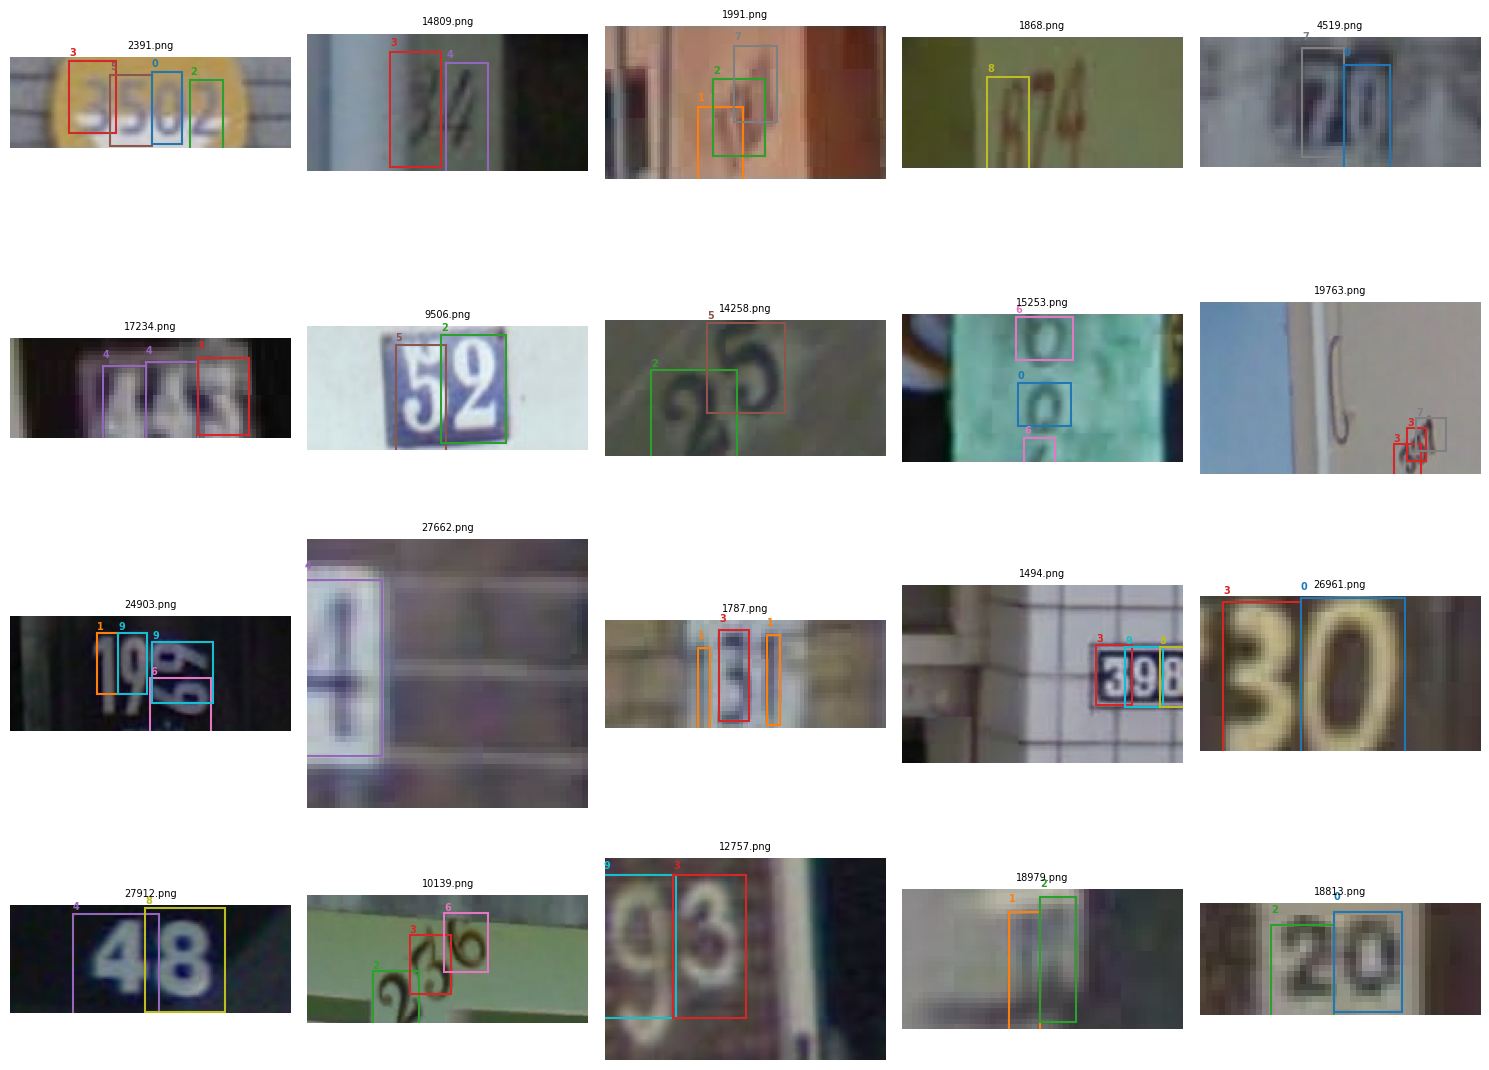

In [53]:
anomaly_img_ids = set(
    [a["image_id"] for a in oob_list] +
    [a["image_id"] for a in dup_anns] +
    [a["image_id"] for a in tiny_anns]
)
print(f"Ảnh có label anomalies: {len(anomaly_img_ids)}")

if anomaly_img_ids:
    sample_anomaly = random.sample(list(anomaly_img_ids), min(20, len(anomaly_img_ids)))
    show_samples(sample_anomaly, TRAIN_DIR)